# Visual-Language Navigation for Legged Robots using RGB Images
## CS 691 Course Project 

### Prerequisites 

Check torch and load CLIP weights

In [1]:
import torch, clip
print(torch.__version__)       
print(torch.cuda.is_available())   
clip.load("ViT-B/32")        

2.11.0+cu130
True


(CLIP(
   (visual): VisionTransformer(
     (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
     (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
     (transformer): Transformer(
       (resblocks): Sequential(
         (0): ResidualAttentionBlock(
           (attn): MultiheadAttention(
             (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
           )
           (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
           (mlp): Sequential(
             (c_fc): Linear(in_features=768, out_features=3072, bias=True)
             (gelu): QuickGELU()
             (c_proj): Linear(in_features=3072, out_features=768, bias=True)
           )
           (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
         )
         (1): ResidualAttentionBlock(
           (attn): MultiheadAttention(
             (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, 

# Data Setup

In [2]:
import numpy as np
from PIL import Image
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import torch

/home/arif/miniconda3/envs/vln/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's load the Navigrace from HuggingFace 

In [3]:
dataset = load_dataset("leggedrobotics/navitrace")
print(f"  Splits available : {list(dataset.keys())}")
print(f"  Validation size  : {len(dataset['validation'])}")
print(f"  Test size        : {len(dataset['test'])}")
 

  Splits available : ['validation', 'test']
  Validation size  : 502
  Test size        : 500


Let's look at one sample 

In [4]:
sample = dataset["validation"][0]


for k, v in sample.items():
    if k == "image":
        print(f"  image  :  Image {v.size}  mode={v.mode}")
    elif k == "segmentation_mask":
        mask = np.array(v)
        print(f"  segmentation_mask  : shape={mask.shape}  dtype={mask.dtype}  "
              f"unique classes={len(np.unique(mask))}")
    elif k == "ground_truth":
        print(f"  ground_truth  : embodiments={list(v.keys())}")
        for emb, traces in v.items():
            if traces is not None:
                lengths = [len(t) for t in traces]
                print(f"    [{emb}]: {len(traces)} trace(s), "
                      f"lengths={lengths}")
            else:
                print(f"    [{emb}]: None")
    elif k == "context":
        print(f"  context : '{v[:80]}...'")
    else:
        print(f"  {k:<22}: {v}")

  sample_id             : 1dfcd2f0-d1db-4197-9ee8-2e573145e9aa
  task                  : Go to the garden
  embodiments           : ['Human', 'Legged Robot']
  image  :  Image (1365, 1024)  mode=RGB
  segmentation_mask  : shape=(1024, 1365)  dtype=int64  unique classes=5
  ground_truth  : embodiments=['Bicycle', 'Human', 'Legged Robot', 'Wheeled Robot']
    [Bicycle]: None
    [Human]: 1 trace(s), lengths=[8]
    [Legged Robot]: 1 trace(s), lengths=[8]
    [Wheeled Robot]: None
  category              : ['Semantic Terrain', 'Geometric Terrain', 'Visibility']
  context : 'Corner of a house; Garden is downstairs behind the house; bike parking area is i...'
  metadata              : {'city': 'Zurich', 'country': 'Switzerland', 'lighting_conditions': 'Daylight', 'natural_structured': 'Structured', 'task_type': 'Goal', 'urban_rural': 'Urban', 'weather_conditions': 'Cloudy'}


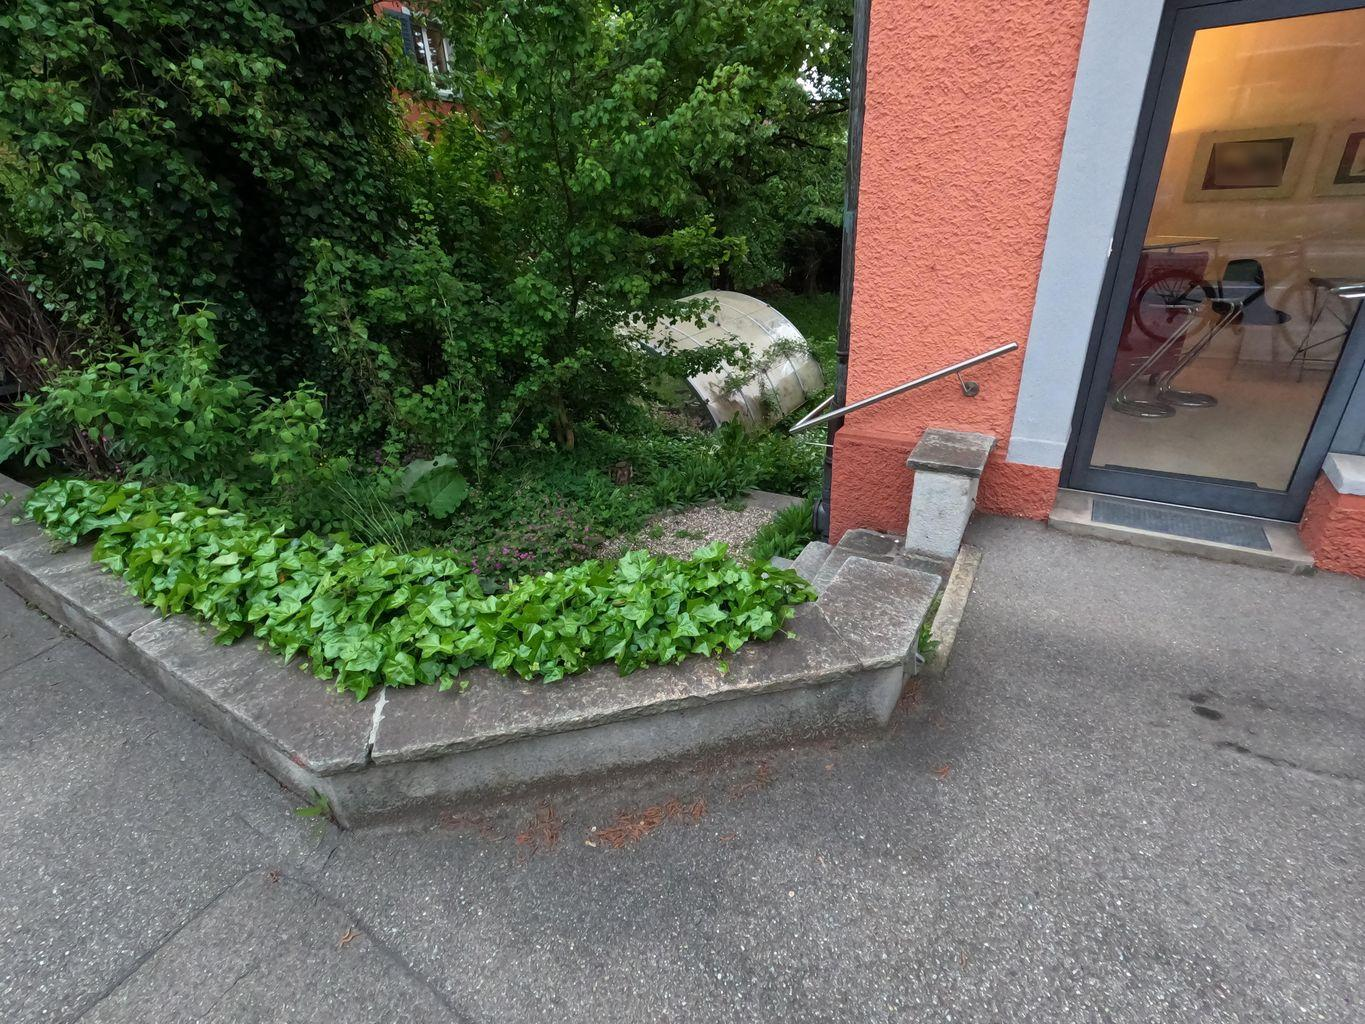

In [5]:
sample['image']

Now, we will filter legged robot samples 

In [6]:
EMBODIMENT = "Legged Robot"

samples, skipped = [], 0
for s in dataset["validation"]:
    gt = s["ground_truth"].get(EMBODIMENT)
    if gt is not None and len(gt) > 0:
        samples.append(s)
    else:
        skipped += 1

print(f"Kept  : {len(samples)}, Skipped : {skipped} ")